# Kaggle Housing Price Prediction — XGBoost Model

XGBoost solution for the [Kaggle Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/competitions/home-data-for-ml-course). Predicts residential home sale prices in Ames, Iowa. The competition metric is MAE on the raw price, but the model is trained on log(SalePrice) to reduce the influence of high-value outliers. This is equivalent to minimising RMSLE.

Exploratory analysis and outlier identification are covered in `data-exploration.ipynb`. This notebook focuses on the modelling pipeline:

1. **Preprocessing**: cleaning, imputation, and ordinal/nominal encoding
2. **Feature engineering**: derived ratios, totals, age features, and neighbourhood-level group statistics
3. **Hyperparameter tuning**: Bayesian optimisation via Optuna
4. **Prediction**: final model fit and submission generation

TODO:
- Think of other interesting features to construct
- Try to combine XGBoost with another boosted tree model like LightGBM

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar

from pandas.api.types import CategoricalDtype

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib
import plotly
import optuna
import optuna.visualization as vis

# set global theme and disable frames
sns.set_theme(style = 'white',
              rc={'legend.frameon': False},
              )
sns.set_style('ticks', {'xtick.major.size' : 8,
                        'ytick.major.size' : 8,
                        'xtick.bottom'     : True,
                        'ytick.left'       : True,
                        })

## Preprocessing

Four functions make up the preprocessing pipeline, each applied to train and test independently to avoid data leakage:

- **`clean()`**: fixes data entry errors (e.g. garage built before the house)
- **`remove_outliers()`**: drops two anomalous developer transactions identified in `data-exploration.ipynb` (applied to training data only)
- **`impute()`**: fills missing values. Statistics that must be learned from training data (e.g. mode of `Electrical`) are stored in `impute_stats` and reused on the test set
- **`encode()`**: nominal columns become unordered `category` dtypes, ordinal columns (quality ratings, condition scores) become ordered `CategoricalDtype` so XGBoost can use them natively via `enable_categorical=True`

In [2]:
def clean(df):
    '''
    Applies preliminary data cleaning to the provided
    dataframe based on the cells above
    '''
    # set missing GarageYrBlt values to YearBuilt
    df.loc[df['GarageYrBlt'] < df['YearBuilt'], 'GarageYrBlt'] = df['YearBuilt']

    return df


def remove_outliers(df):
    '''
    Two Edwards neighbourhood partial sales identified in data-exploration.ipynb that
    seem like outliers. Large area, good quality, but low price. Remove these
    from the training data
    '''
    mask = ((df['Neighborhood'] == 'Edwards') &
            (df['SaleCondition'] == 'Partial') &
            (df['GrLivArea'] > 4000))
    
    return df[~mask]


def impute(df, impute_stats=None):
    '''
    Impute the columns in the provided dataframe
    based on the results of the cells above

    impute_stats is a dict that specifies values to
    use for imputing that need to be collected from
    training data 
    '''
    # first handle special cases

    # estimate missing LotFrontage by the root of LotArea
    df['RootArea']    = np.sqrt(df['LotArea'])
    df['LotFrontage'] = df['LotFrontage'].fillna(df['RootArea'])
    df = df.drop(columns=['RootArea'])

    # set missing GarageYrBlt with YearBuilt
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    # impute the missing Electrical data with the mode
    if impute_stats is None:
        impute_stats = {'Electrical' : df['Electrical'].mode()[0]}
    
    df['Electrical'] = df['Electrical'].fillna(impute_stats['Electrical'])


    # general handling for the rest of the columns
    for col in df.select_dtypes('object', 'category'):
        df[col] = df[col].fillna('NA')
    
    for col in df.select_dtypes('number'):
        df[col] = df[col].fillna(0)
    
    return df, impute_stats


def encode(df):
    '''
    Encode the categorical columns of the provided dataframe
    based on the encoding outlined below
    '''
    # categorical columns
    categorical_cols = set(df.select_dtypes('object', 'category').columns)

    nominative_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
                    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
                    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'Functional',
                    'MiscFeature', 'SaleType', 'SaleCondition', 'GarageType']

    ordinal_cols = list(categorical_cols - set(nominative_cols))

    ordinal_encoding = {'LotShape'      : ['Reg', 'IR1', 'IR2', 'IR3'],
                        'LandSlope'     : ['Gtl', 'Mod', 'Sev'],
                        'ExterQual'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'ExterCond'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtQual'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtCond'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtExposure'  : ['No', 'Mn', 'Av', 'Gd'],
                        'BsmtFinType1'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'BsmtFinType2'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'HeatingQC'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'CentralAir'    : ['N', 'Y'],
                        'KitchenQual'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'FireplaceQu'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageQual'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageCond'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageFinish'  : ['Unf', 'RFn', 'Fin'],
                        'PavedDrive'    : ['N', 'P', 'Y'],
                        'PoolQC'        : ['Fa', 'TA', 'Gd', 'Ex'],
                        'Fence'         : ['MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
                        }

    ordinal_encoding = {key: ['NA'] + values for key, values in ordinal_encoding.items()}

    for col in nominative_cols:
        df[col] = df[col].astype('category')
    
    for col in ordinal_cols:
        df[col] = df[col].astype(CategoricalDtype(ordinal_encoding[col], ordered=True))
    
    return df

## Load Data

Apply the full preprocessing pipeline. The `impute_stats` dict is fit on the training set and passed through to the test set so the test data never influences any computed statistics.

In [3]:
def load_data():
    # Load the Kaggle dataset
    path_train = './input/train.csv.gz'
    path_test  = './input/test.csv.gz'

    train_full = pd.read_csv(path_train, compression='gzip', index_col='Id')
    test_full  = pd.read_csv(path_test, compression='gzip', index_col='Id')

    train = train_full.copy()
    train = clean(train)
    train = remove_outliers(train)
    train, impute_stats = impute(train)
    train = encode(train)

    test = test_full.copy()
    test = clean(test)
    test, _ = impute(test, impute_stats)
    test = encode(test)

    return train, test

train, test = load_data()

print(f'Shape of train dataset: {train.shape}')
print(f'Shape of test dataset:  {test.shape}')

# remove training rows with missing target (SalePrice)
print(f'{train["SalePrice"].isna().sum()} trainig rows have a missing SalePrice')
train = train.dropna(subset=['SalePrice']) # no missing SalePrice so not needed

# remove any duplicate training rows
print(f'{train.duplicated().sum()} trainig rows are duplicates')
train = train.drop_duplicates(keep='first') # no duplicates so not needed

Shape of train dataset: (1458, 80)
Shape of test dataset:  (1459, 79)
0 trainig rows have a missing SalePrice
0 trainig rows are duplicates


## Baseline Model

Establish a baseline score using default XGBoost hyperparameters on the raw features before any feature engineering. The scoring function uses 5-fold cross-validation and reports RMSE on log(`SalePrice`), consistent with the competition's RMSLE metric.

In [4]:
def score_model(X, y, model=XGBRegressor(enable_categorical=True, random_state=123)):
    '''
    Return a score using cross validation to estimate
    model performance. This competition uses RMSE between
    log prices so use that as a metric
    '''    
    log_y = np.log(y)
    score = cross_val_score(model, X, log_y, cv=5, scoring='neg_mean_squared_error')
    score = -1 * score.mean()
    score = np.sqrt(score)

    return score

In [5]:
X = train.copy()
y = X.pop('SalePrice')

baseline_score = score_model(X, y)
print(f'Baseline model score: {baseline_score:.5f} RMSE')

Baseline model score: 0.13348 RMSE


## Feature Selection via Mutual Information

Mutual information measures the statistical dependence between each feature and the target, capturing non-linear relationships that a simple correlation would miss. Columns with zero MI score carry no useful signal and are dropped to reduce the risk of overfitting.

In [6]:
def get_mi_scores(X, y):
    '''
    Calculate mutual information scores between columns
    in X and target in y
    '''
    X = X.copy()
    for col in X.select_dtypes(['category']):
        X[col] = X[col].cat.codes

    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=123)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    return mi_scores


def plot_mi_scores(scores):
    '''
    Create a bar plot of mutual information scores
    '''
    scores = scores.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(4, 12))

    sns.barplot(x=scores.values, y=scores.index)

    ax.tick_params(axis='both', labelsize=8)
    ax.set_ylabel('Column')
    ax.set_xlabel('Mutual Information Score')
    
    plt.show()

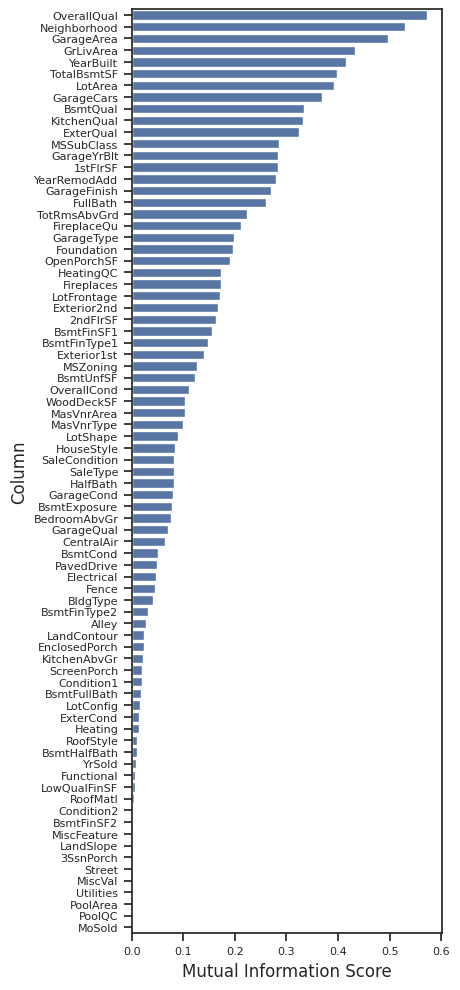

In [7]:
X = train.copy()
y = X.pop('SalePrice')

mi_scores = get_mi_scores(X, y)
plot_mi_scores(mi_scores)

In [8]:
# Delete columns with 0 mutual information so model isn't overfitting.
# Some columns like Poolxxx are mostly 0 or NA because most houses
# don't have pools

def drop_uninformative(df, mi_scores):
    return df.loc[:, mi_scores > 0.0]

X = train.copy()
y = X.pop('SalePrice')
X = drop_uninformative(X, mi_scores)

# score here increases but removing these could help with overfitting
print(f'Score after removing uninformative features: {score_model(X, y):.5f} RMSE')

Score after removing uninformative features: 0.13606 RMSE


## Feature Engineering

Construct additional features from the raw columns. These fall into a few categories:

- **Ratios and Products**: ex. relative size of the house vs the lot
- **Totals**: ex. combined square footage
- **Ages**: ex. years since the house was built
- **Presence flags**: ex. binary flag for a house having a garage
- **Neighbourhood statistics**: ex. median of living area per neighbourhood (computed on training data only to prevent leakage)

In [9]:
def combinations(df):
    '''
    Creates a dataframe of new columns X which
    are meaningful mathematical transformations
    of the columns in df 
    '''
    X = pd.DataFrame(index=df.index)

    # ratios
    X['LivLotRatio']   = df['GrLivArea'] / df['LotArea'] # size of house vs size of property
    X['PorchLotRatio'] = df[['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].sum(axis=1) / df['LotArea'] # how much of the lot is covered by decks
    X['Spaciousness']  = (df['1stFlrSF'] + df['2ndFlrSF']) / df['TotRmsAbvGrd'] # are the rooms spacious

    # products
    X['QualArea']     = df['OverallQual'] * df['GrLivArea'] # more area of higher quality should be more expensive

    # totals
    X['TotBath']      = df[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * df[['BsmtHalfBath', 'HalfBath']].sum(axis=1) # total bathroom count
    X['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] # total interior SF

    # ages
    X['Age']          = df['YrSold'] - df['YearBuilt'] # how old is the house explicitly (newer houses should be more expensive?)
    X['AgeOfRemod']   = df['YrSold'] - df['YearRemodAdd'] # how old is the remodel (more recent also more expensive?)

    # flags
    X['HasGarage']    = (~df['GarageYrBlt'].isna()).astype(int) # is there a garage?
    X['HasBasement']  = (~df['TotalBsmtSF'].eq(0)).astype(int) # is there a basement?

    return X


def group_transforms(df, group_stats=None):
    '''
    Creates a dataframe of new columns which are group-level
    statistics per Neighborhood, computed from training data only.

    group_stats: dict of pre-computed Series (fit on train).
                 If None, stats are computed from df — only pass
                 None when df is the training set.
    '''
    if group_stats is None:
        group_stats = {
            'MedNhbdLivArea'  : df.groupby('Neighborhood', observed=False)['GrLivArea'].median(),
            'StdvNhbdLivArea' : df.groupby('Neighborhood', observed=False)['GrLivArea'].std(),
            'MeanNhbdLotArea' : df.groupby('Neighborhood', observed=False)['LotArea'].mean(),
        }

    X = pd.DataFrame(index=df.index)
    X['MedNhbdLivArea']  = df['Neighborhood'].map(group_stats['MedNhbdLivArea']).astype(float)
    X['StdvNhbdLivArea'] = df['Neighborhood'].map(group_stats['StdvNhbdLivArea']).astype(float)
    X['MedNhbdLivDiff']  = df['GrLivArea'] - X['MedNhbdLivArea']
    X['MeanNhbdLotArea'] = df['Neighborhood'].map(group_stats['MeanNhbdLotArea']).astype(float)

    return X, group_stats

In [10]:
X = train.copy()
y = X.pop('SalePrice')

X = drop_uninformative(X, mi_scores) # removing these columns seems to make the score worse
X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

print(f'Model score: {score_model(X, y):.5f} RMSE')

Model score: 0.13236 RMSE


## Final Feature Set

Assemble the complete feature set used for training and prediction. The `group_stats` dict (neighbourhood medians/stds) is fit on the training set and applied to the test set to prevent leakage of the test dataset.

In [11]:
def create_features(df, df_test=None):
    '''
    Combined function to set up all the model features based on
    Feature Engineering for Housing Prices Kaggle notebook
    '''
    X = df.copy()
    y = X.pop('SalePrice')

    mi_scores = get_mi_scores(X, y)

    # Choose not to combine splits to avoid leakage of test data
    # into train data. This would probably give better performance
    # for the Kaggle competition but probably not good when
    # making a general model that is supposed to predict unseen data

    X = drop_uninformative(X, mi_scores) # seems to make the model perform worse
    X = X.join(combinations(X))

    group_features, group_stats = group_transforms(X)
    X = X.join(group_features)

    # set up test data
    if df_test is not None:
        X_test = df_test.copy()

        X_test = drop_uninformative(X_test, mi_scores)
        X_test = X_test.join(combinations(X_test))

        test_group_features, _ = group_transforms(X_test, group_stats)
        X_test = X_test.join(test_group_features)

        return X, X_test
    else:
        return X

## Hyperparameter Tuning with Optuna

Optuna uses Bayesian optimisation to search the hyperparameter space. Each trial informs the next, making it more efficient than random search for the same number of trials. The objective function is 5-fold cross-validated log-RMSE on the training set.

In [12]:
df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train['SalePrice']

log_y_train = np.log(y_train)

### Tune XGBoost

In [13]:
def objective_XGB(trial):
    params = {'n_estimators'     : trial.suggest_int('n_estimators', 500, 2000),
              'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
              'max_depth'        : trial.suggest_int('max_depth', 3, 10),
              'subsample'        : trial.suggest_float('subsample', 0.2, 1.0),
              'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.2, 1.0),
              'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
              'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
              'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
              }

    model = XGBRegressor(**params, enable_categorical=True, random_state=123)

    # this method doesn't take advantage of early_stopping_rounds so keep an eye on
    # n_estimators to make sure the model isn't using all the trees and overfitting
    scores = cross_val_score(model, X_train, log_y_train, cv=5, scoring='neg_mean_squared_error')

    return np.sqrt(-scores.mean())

In [14]:
# load cached study
xgb_study = joblib.load('./optuna-cache/xgb-optuna-study.joblib')

# # rerun study
# xgb_study = optuna.create_study(direction='minimize')
# xgb_study.optimize(objective_XGB, n_trials=50)

# # cache hyperparameter optimization so it doesn't have to rerun
# joblib.dump(xgb_study, './optuna-cache/xgb-optuna-study.joblib')

print(f'Best RMSE:   {xgb_study.best_value:.5f}')
print(f'Best params: {xgb_study.best_params}')

Best RMSE:   0.11157
Best params: {'n_estimators': 1546, 'learning_rate': 0.011799228792910956, 'max_depth': 4, 'subsample': 0.4403626996444446, 'colsample_bytree': 0.6565271101764816, 'min_child_weight': 2, 'reg_alpha': 0.025833746431259567, 'reg_lambda': 0.2512155621917321}


### Tune LightGBM

In [15]:
def to_lgbm_features(X):
    '''
    Convert ordinal CategoricalDtype columns to integer codes so that
    LightGBM can understand the ranking
    '''
    X = X.copy()
    for col in X.select_dtypes('category'):
        if X[col].cat.ordered:
            X[col] = X[col].cat.codes

    return X


def objective_LGBM(trial):
    params = {'n_estimators'      : trial.suggest_int('n_estimators', 500, 2000),
              'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
              'num_leaves'        : trial.suggest_int('num_leaves', 15, 100),
              'subsample'         : trial.suggest_float('subsample', 0.2, 1.0),
              'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.2, 1.0),
              'min_child_samples' : trial.suggest_int('min_child_samples', 15, 40),
              'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
              'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
              }

    model  = LGBMRegressor(**params, boosting_type='gbdt', subsample_freq=1, verbose=-1, random_state=123)
    scores = cross_val_score(model, to_lgbm_features(X_train), log_y_train, cv=5, scoring='neg_mean_squared_error')

    return np.sqrt(-scores.mean())

In [17]:
# load cached study
lgbm_study = joblib.load('./optuna-cache/lgbm-optuna-study.joblib')

# rerun study
# lgbm_study = optuna.create_study(direction='minimize')
# lgbm_study.optimize(objective_LGBM, n_trials=50)

# # cache hyperparameter optimization so it doesn't have to rerun
# joblib.dump(lgbm_study, './optuna-cache/lgbm-optuna-study.joblib')

print(f'Best RMSE:   {lgbm_study.best_value:.5f}')
print(f'Best params: {lgbm_study.best_params}')

Best RMSE:   0.11574
Best params: {'n_estimators': 1877, 'learning_rate': 0.006644711482410608, 'num_leaves': 16, 'subsample': 0.8439183915169166, 'colsample_bytree': 0.2527597739939762, 'min_child_samples': 15, 'reg_alpha': 0.04056737384144525, 'reg_lambda': 3.5201520578336436}


### Visualize Hyperparameter Tuning

In [19]:
study = lgbm_study # lgbm_study

# how the objective value improved over trials
vis.plot_optimization_history(study).show()

# which hyperparameters mattered most
# vis.plot_param_importances(study).show()

# 2D slice of the objective surface
# vis.plot_contour(study, params=['learning_rate', 'reg_alpha']).show()

# distribution of sampled values vs objective score
# vis.plot_slice(study).show()

## Optimize Combination Weights of BDT Models
Tune weights of optimized models using their out-of-fold CV predictions.

scipy.optimize.minimize_scalar over α ∈ [0, 1] to minimise the ensemble RMSE:

$$\textrm{prediction}_\textrm{ensemble} = \alpha \times \textrm{prediction}_\mathrm{XGB} + (1 - \alpha) \times \textrm{prediction}_\mathrm{LGBM}$$

In [ ]:
xgb  = XGBRegressor(**xgb_study.best_params, enable_categorical=True, random_state=123)
lgbm = LGBMRegressor(**lgbm_study.best_params, boosting_type='gbdt', subsample_freq=1, verbose=-1, random_state=123)

# generate out-of-fold predictions for each model
xgb_oof  = cross_val_predict(xgb, X_train, log_y_train, cv=5)
lgbm_oof = cross_val_predict(lgbm, to_lgbm_features(X_train), log_y_train, cv=5)

# score function to minimize
def objective_ensemble(alpha):
    ensemble_preds = alpha * xgb_oof + (1 - alpha) * lgbm_oof
    return np.sqrt(np.mean((ensemble_preds - log_y_train) ** 2))

result = minimize_scalar(objective_ensemble, bounds=(0, 1), method='bounded')
alpha  = result.x

print(f'Optimal α:      {alpha:.4f}')
print(f'XGB-only RMSE:  {objective_ensemble(1.0):.5f}')
print(f'LGBM-only RMSE: {objective_ensemble(0.0):.5f}')
print(f'Ensemble RMSE:  {objective_ensemble(alpha):.5f}')

Optimal alpha:  0.8569  (1.0 = XGB only, 0.0 = LGBM only)
XGB-only RMSE:  0.11158
LGBM-only RMSE: 0.11575
Ensemble RMSE:  0.11146


## Generate Predictions

Refit the model on the full training set using the best hyperparameters found by Optuna, then predict on the test set. Predictions are exponentially scaled to convert back from log-price to price before writing.

In [ ]:
X_train, X_test = create_features(df_train, df_test)
y_train         = df_train['SalePrice']

xgb = XGBRegressor(**xgb_study.best_params, enable_categorical=True)

# log transform because competition is looking at error in log price
xgb.fit(X_train, np.log(y_train))
predictions = np.exp(xgb.predict(X_test)) # convert log price back to regular price

output = pd.DataFrame({'Id': X_test.index,
                       'SalePrice': predictions,
                       })
output.to_csv('./output/xgb-submission.csv', index=False)